# Detección de anomalías en el borde con Isolation Forest (ESP32)

Pipeline: **ESP32 (DHT11 + LDR + PIR) → Google Sheets → entrenamiento en scikit-learn → exportación a MicroPython → inferencia en el propio ESP32.**

Este notebook cubre la parte de datos y modelo: exploración, limpieza, entrenamiento, exportación y validación de que el modelo portado coincide con scikit-learn.

> **Nota sobre la validación:** el 100 % de coincidencia de la sección 6 mide la *fidelidad del port* respecto a scikit-learn, no la calidad de la detección: el aprendizaje no supervisado no dispone de etiquetas reales de anomalía.

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "tools"))      # export_iforest_upy
sys.path.insert(0, str(ROOT / "firmware"))   # isolation_forest, if_data

## 1. Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQAffxLuBjV0vd7tF24QAHWscKrPY7W-b4phSzykkRHzt9MTNSQI0WpB7ynRvaHUBDj6qsxKUYXEdw9/pub?output=csv"

#Procedemos a leer los datos del Google Sheet
print("Leyendo datos de la nube")
df = pd.read_csv(url)



Leyendo datos de la nube


## 2. Exploración y limpieza

Se descartan lecturas de temperatura incoherentes (fallos del DHT11) y se invierte la escala del LDR para que *más valor = más luz*.

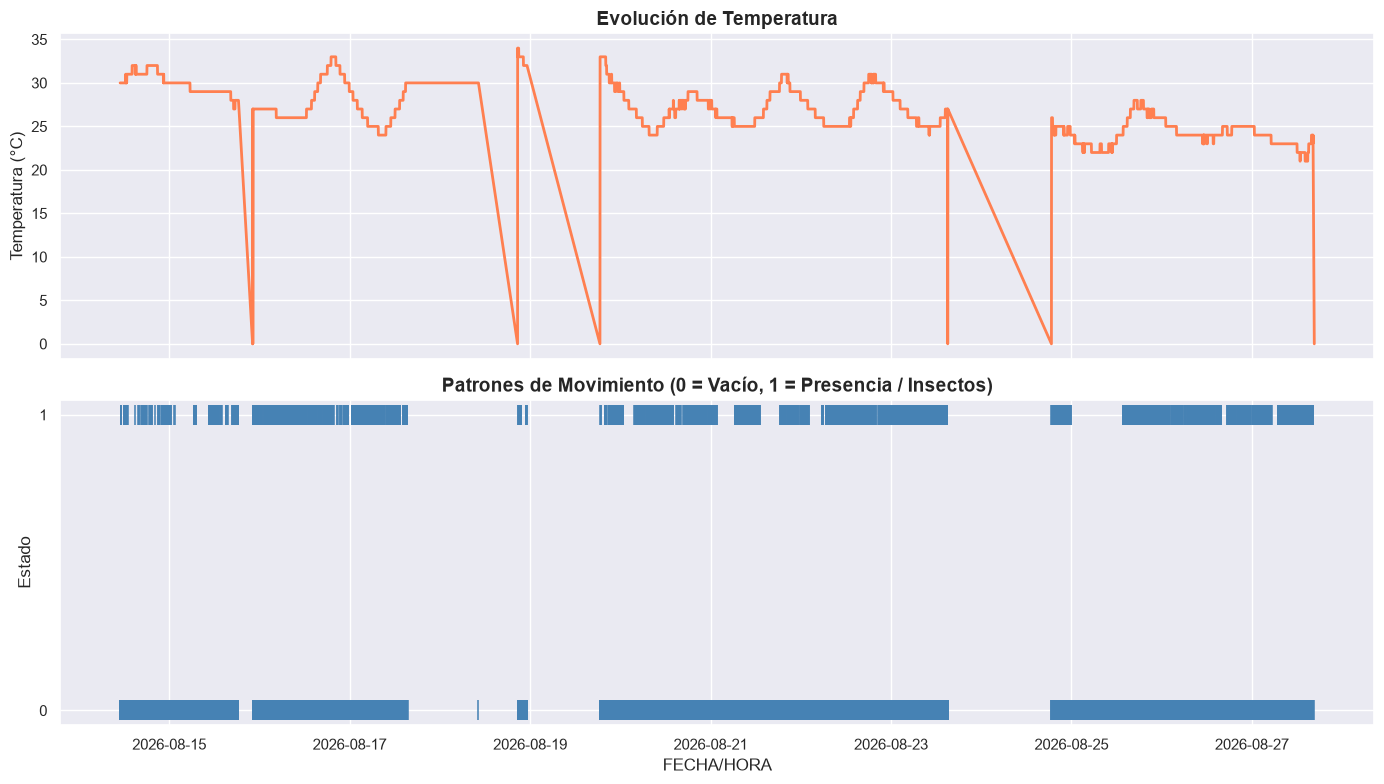

Datos antes de la limpieza: 13141
Datos tras la limpieza: 13133
Datos eliminados: 8
Nueva gráfica:

Vacío: 10333 registros (78.7%)
Presencia: 2800 registros (21.3%)
                 LUZ  MOVIMIENTO
LUZ         1.000000    0.038831
MOVIMIENTO  0.038831    1.000000


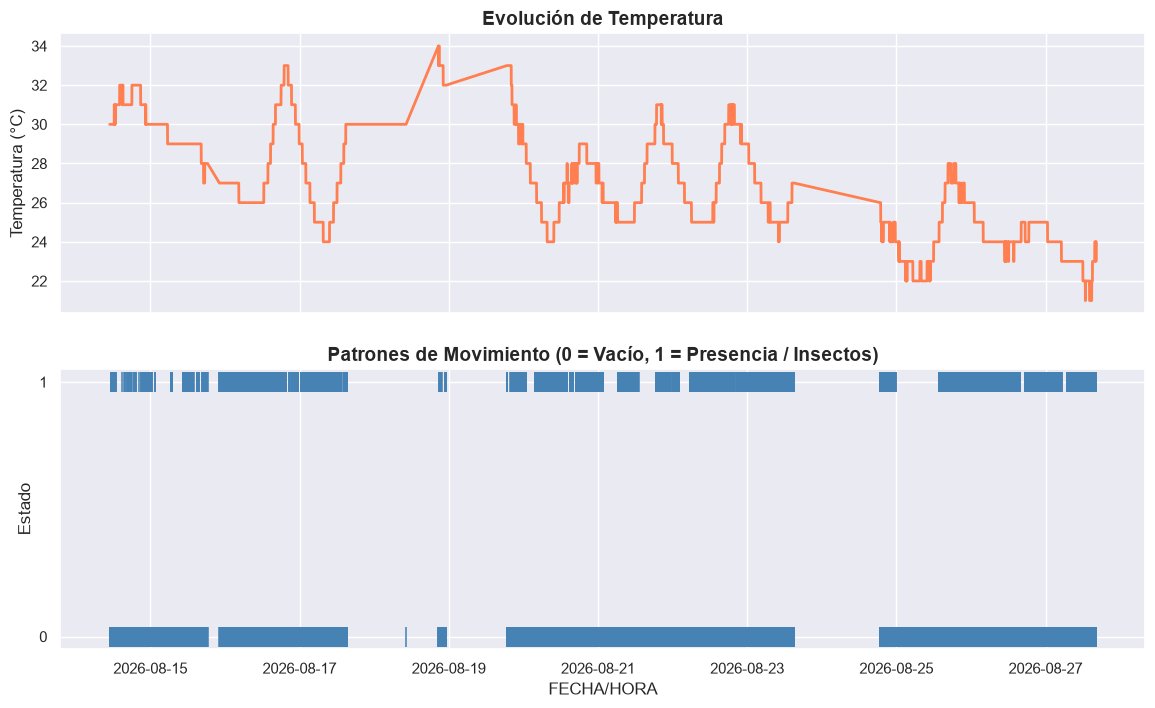

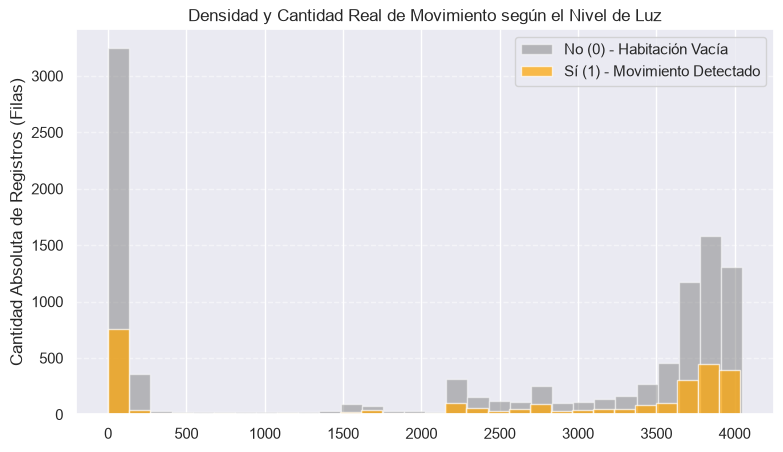

In [3]:
#REPRESENTACIÓN DE DATOS:

#Tranfromamos los datos de la fecha y hora a df de Pandas
df['FECHA/HORA'] = pd.to_datetime(df['FECHA/HORA'])
#Theme : Darkgrid
sns.set_theme(style="darkgrid")
#Generamos la representación con dos sub gráficos apilados
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
#Gráfica Superior: Evolución de la Temperatura

sns.lineplot(data=df, x = "FECHA/HORA", y= "TEMP", ax= axes[0], color = "coral", linewidth = 2)
axes[0].set_title("Evolución de Temperatura", fontsize = 14, fontweight = "bold")
axes[0].set_ylabel("Temperatura (°C)")

#Gráfica Inferior: Detección de Movimiento (0 y 1) 
#Usamos un gráfico de dispersión (puntos/líneas verticales) porque es una variable binaria
sns.scatterplot(data=df, x="FECHA/HORA", y="MOVIMIENTO", ax=axes[1], color="steelblue", marker="|", s=200)
axes[1].set_title("Patrones de Movimiento (0 = Vacío, 1 = Presencia / Insectos)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Estado")
axes[1].set_yticks([0, 1]) 




plt.tight_layout()
plt.show()

#Limpieza de datos (Temperatura incoherente)
df_clean = df[df["TEMP"]>10].copy()

#Efectos de la limpieza
print("Datos antes de la limpieza:", len(df))
print("Datos tras la limpieza:", len(df_clean))
print("Datos eliminados:",len(df)- len(df_clean))
print("Nueva gráfica:\n")
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
#Gráfica Superior: Evolución de la Temperatura

sns.lineplot(data=df_clean, x = "FECHA/HORA", y= "TEMP", ax= axes[0], color = "coral", linewidth = 2)
axes[0].set_title("Evolución de Temperatura", fontsize = 14, fontweight = "bold")
axes[0].set_ylabel("Temperatura (°C)")

#Gráfica Inferior: Detección de Movimiento (0 y 1) 
#Usamos un gráfico de dispersión (puntos/líneas verticales) porque es una variable binaria
sns.scatterplot(data=df_clean, x="FECHA/HORA", y="MOVIMIENTO", ax=axes[1], color="steelblue", marker="|", s=200)
axes[1].set_title("Patrones de Movimiento (0 = Vacío, 1 = Presencia / Insectos)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Estado")
axes[1].set_yticks([0, 1]) 

# Invertimos la escala para que "más valor" realmente sea "más luz"
df_clean["LUZ"] = 4095 - df_clean["LUZ"]
#Análisis de distribución de movimiento

conteo = df_clean["MOVIMIENTO"].value_counts()
porcentajes = df_clean["MOVIMIENTO"].value_counts(normalize = True)*100

for estado in conteo.index:
    etiqueta = "Presencia" if estado == 1 else "Vacío"
    cantidad  = conteo[estado]
    porcentaje = porcentajes[estado]
    print(f"{etiqueta}: {cantidad} registros ({porcentaje:.1f}%)")
print(df_clean.loc[:,["LUZ","MOVIMIENTO"]].corr())

# Aseguramos datos numéricos y limpiamos nulos
df_clean["MOVIMIENTO"] = pd.to_numeric(df_clean["MOVIMIENTO"], errors="coerce")
df_clean["LUZ"] = pd.to_numeric(df_clean["LUZ"], errors="coerce")
df_grafico = df_clean.dropna(subset=["MOVIMIENTO", "LUZ"])

# Separamos los datos de luz por estado de movimiento
luz_sin_movimiento = df_grafico[df_grafico["MOVIMIENTO"] == 0]["LUZ"]
luz_con_movimiento = df_grafico[df_grafico["MOVIMIENTO"] == 1]["LUZ"]

# Creamos el histograma de frecuencias absolutas
plt.figure(figsize=(9, 5))

# Graficamos el grupo sin movimiento
plt.hist(luz_sin_movimiento, bins=30, alpha=0.5, label="No (0) - Habitación Vacía", color="gray")

# Graficamos el grupo con movimiento
plt.hist(luz_con_movimiento, bins=30, alpha=0.7, label="Sí (1) - Movimiento Detectado", color="orange")

# Etiquetas
plt.title("Densidad y Cantidad Real de Movimiento según el Nivel de Luz")
plt.ylabel("Cantidad Absoluta de Registros (Filas)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()



## 3. Entrenamiento del Isolation Forest

15 árboles y `max_samples=256` para que el modelo quepa en la RAM del ESP32; `contamination=0.01` como proporción esperada de anomalías.

In [4]:
#CREACIÓN DEL MODELO: ISOLATION FOREST
from sklearn.ensemble import IsolationForest

#Modificamos la fecha del dataframe para obtener solo la hora
df_clean["HORA"] = df_clean["FECHA/HORA"].dt.hour

#Hacemos una selección de las columnas que se van a utilizar
columnas_entrenamiento  = ["HORA","TEMP","MOVIMIENTO","HUMEDAD","LUZ"]
X = df_clean[columnas_entrenamiento]

#Creamos el modelo con un 1% de contamination
modelo = IsolationForest(n_estimators=15, max_samples=256, contamination=0.01, random_state=42)

#Entrenamiento
print("------Entrenamiento en proceso------")
modelo.fit(X)

#El modelo etiquetará 1 si es un estado normal
#Y etiquetará -1 si el dato es una anomalía
df_clean["ANOMALÍA"] = modelo.predict(X)

print("Fin del entrenamiento")
print(df_clean["ANOMALÍA"].value_counts())

# Filtramos únicamente las filas marcadas como anomalía (-1)
df_anomalos = df_clean[df_clean["ANOMALÍA"] == -1]
# Exportamos a un archivo CSV limpio
# 'index=False' evita que se guarde una columna extra con los números de fila viejos
df_anomalos.to_csv("anomalias_esp32.csv", index=False)

print("Archivo 'anomalias_esp32.csv' generado con éxito en su carpeta")

------Entrenamiento en proceso------
Fin del entrenamiento
ANOMALÍA
 1    13001
-1      132
Name: count, dtype: int64
Archivo 'anomalias_esp32.csv' generado con éxito en su carpeta


## 4. Enfoque descartado: aproximación lineal

Primer intento: sustituir el bosque por un clasificador lineal (pesos = diferencia de medias normalizada entre normales y anómalos, umbral en el punto medio) para que cupiera cómodamente en el ESP32. Producía demasiados falsos positivos frente a las etiquetas de `IsolationForest`, así que se descartó.

Segundo intento: exportar el modelo a C con `m2cgen`, que no es compatible con `IsolationForest`.

Solución final: exportar los árboles tal cual (arrays compactos) e implementar la inferencia en MicroPython (sección 5).

## 5. Exportación a MicroPython

In [5]:
#Como ya hemos comprobado, no podemos usar ese método para aproximar los humbrales, por los excesivos falsos positivos
#Una segunda aproximación fue usar m2cgem para exportar a C el código, lo cual se vio frustrado por la incompatibilidad
# de m2cgen con los modelos de tipo Isolation forest:
# import m2cgen as m2c
# codigo_cpp = m2c.export_to_c(modelo)
# with open("IsolationForestES32.h","w") as archivo:
#     archivo.write("// Modelo de Machine Learning autogenerado por m2cgen \n")
#     archivo.write(codigo_cpp)

#Por lo que en definitiva exportaremos el modelo a mano:

from export_iforest_upy import export_isolation_forest_micropython

export_isolation_forest_micropython(modelo, ROOT / "firmware" / "if_data.py",
                                    threshold=0.630481, feature_names=columnas_entrenamiento)


Exportado 15 arboles, 2881 nodos totales.
RAM estimada para los arrays: ~34572 bytes (~33.8 KB)
Archivo: if_data.py
Sube este archivo al ESP32 con Thonny junto con isolation_forest.py


## 6. Validación del port y calibración del umbral

Se compara el score del ESP32 (`isolation_forest.py`) con `modelo.predict` de scikit-learn y se ajusta el umbral en el punto medio entre la anomalía menos extrema y el dato normal más extremo.

In [6]:
import pandas as pd
from isolation_forest import anomaly_score, is_anomaly 

features = ["HORA", "TEMP", "MOVIMIENTO", "HUMEDAD", "LUZ"]
X = df_clean[features]

# Scikit-Learn devuelve -1 para anomalía y 1 para normal
sk_preds = modelo.predict(X)
sk_is_anomaly = (sk_preds == -1)

exp_scores = []
exp_is_anomaly_orig = []

# 1. EVALUACIÓN INICIAL (usando el umbral por defecto cargado en if_data)
for _, row in X.iterrows():
    sample = row.tolist()
    exp_scores.append(anomaly_score(sample))
    # Al no pasar parámetro, usará _d.THRESHOLD (el valor original)
    exp_is_anomaly_orig.append(is_anomaly(sample)) 

# DataFrame de comparación
df_comp = df_clean[features].copy()
df_comp["SK_Anomalia"] = sk_is_anomaly
df_comp["EXP_Anomalia_Orig"] = exp_is_anomaly_orig
df_comp["EXP_Score"] = exp_scores
df_comp["Difieren_Orig"] = df_comp["SK_Anomalia"] != df_comp["EXP_Anomalia_Orig"]

print("=== 1. COMPARACIÓN CON UMBRAL ORIGINAL ===")
print(f"Total de registros: {len(df_comp)}")
print(f"Anomalías reales (SKLearn):    {df_comp['SK_Anomalia'].sum()}")
print(f"Anomalías detectadas (ESP32):  {df_comp['EXP_Anomalia_Orig'].sum()}")
print(f"Total de discrepancias:        {df_comp['Difieren_Orig'].sum()}\n")

# 2. CÁLCULO DEL NUEVO UMBRAL
# Obtenemos los límites en base a los scores crudos
min_score_anomalia = df_comp[df_comp['SK_Anomalia'] == True]['EXP_Score'].min()
max_score_normal = df_comp[df_comp['SK_Anomalia'] == False]['EXP_Score'].max()

print("=== 2. AJUSTE DE UMBRAL ===")
print(f"Puntuación mínima de anomalía (SK): {min_score_anomalia:.6f}")
print(f"Puntuación máxima de dato normal (SK): {max_score_normal:.6f}")

nuevo_umbral = (min_score_anomalia + max_score_normal) / 2
print(f"EL NUEVO UMBRAL RECOMENDADO ES: {nuevo_umbral:.6f}\n")

# 3. VERIFICACIÓN FINAL USANDO TU FUNCIÓN DEFINIDA
exp_is_anomaly_nuevo = []

for _, row in X.iterrows():
    sample = row.tolist()
    # AQUÍ ESTÁ LA CLAVE: Pasamos el umbral explícitamente a la función del ESP32
    exp_is_anomaly_nuevo.append(is_anomaly(sample, threshold=nuevo_umbral))

df_comp["EXP_Anomalia_Nuevo"] = exp_is_anomaly_nuevo
df_comp["Difieren_Nuevo"] = df_comp["SK_Anomalia"] != df_comp["EXP_Anomalia_Nuevo"]

print("=== 3. VERIFICACIÓN CON NUEVO UMBRAL ===")
print(f"Anomalías detectadas ahora: {df_comp['EXP_Anomalia_Nuevo'].sum()}")
print(f"Nuevas discrepancias:       {df_comp['Difieren_Nuevo'].sum()}")

if df_comp['Difieren_Nuevo'].sum() == 0:
    print("¡ÉXITO! El modelo exportado ahora coincide al 100% con scikit-learn.")
else:
    print("Aún hay diferencias. Revisa las distribuciones de los scores.")

=== 1. COMPARACIÓN CON UMBRAL ORIGINAL ===
Total de registros: 13133
Anomalías reales (SKLearn):    132
Anomalías detectadas (ESP32):  81
Total de discrepancias:        51

=== 2. AJUSTE DE UMBRAL ===
Puntuación mínima de anomalía (SK): 0.625496
Puntuación máxima de dato normal (SK): 0.625399
EL NUEVO UMBRAL RECOMENDADO ES: 0.625447

=== 3. VERIFICACIÓN CON NUEVO UMBRAL ===
Anomalías detectadas ahora: 132
Nuevas discrepancias:       0
¡ÉXITO! El modelo exportado ahora coincide al 100% con scikit-learn.


## 7. Guardar el umbral calibrado

In [ ]:
# Guarda el umbral calibrado en el modelo que se subirá al ESP32
from export_iforest_upy import update_threshold
update_threshold(ROOT / "firmware" / "if_data.py", nuevo_umbral)